In [3]:
import pandas as pd
from pandas.api.types import CategoricalDtype
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
from scipy.stats import describe
import missingno as msno

Funciones auxiliares

In [4]:
# FUNCIONES AUXILIARES
def plot_histograma(data, column, figsize=(6, 3), bins=15, kde=True, mvd=True, shade=True, snk=False):
    skewness = (data[column]).skew()
    kurtosis = (data[column]).kurt()
    media = (data[column]).mean()
    var = (data[column]).var()
    std = (data[column]).std()
    
    plt.figure(figsize=figsize)
    plt.grid(axis='y')
    sns.histplot(data[column], bins=bins, kde=kde)
    
    if snk:
        plt.figtext(0.7, 0.8, f'Asimetría: {skewness:.2f}', fontsize=10, color='blue')
        plt.figtext(0.715, 0.73, f'Curtosis: {kurtosis:.2f}', fontsize=10, color='blue')
        plt.axvline(media, color='red', linestyle='--', label='Media')

    if mvd and shade:
        plt.axvspan(media - std, media + std, alpha=0.1, color='orange', label='±1 Std')
        plt.axvline(media + std, color='orange', linestyle=':', label='+1 Std')
        plt.axvline(media - std, color='orange', linestyle=':', label='-1 Std')
        plt.figtext(0.15, 0.80, f'Media: {media:.2f}', fontsize=10, color='red')
        plt.figtext(0.15, 0.73, f'Var:   {var:.2f}',   fontsize=10, color='red')
        plt.figtext(0.15, 0.66, f'Std:   {std:.2f}',   fontsize=10, color='orange')

    plt.title(f'Variable: {column}')
    plt.xlabel(f'{column}')
    plt.ylabel('Frecuencia')
    plt.show()

Carga y limpieza de datos

In [8]:
df_csv = pd.read_csv("datasets/smn_historico.csv")

df_csv.info()

print("cantidad de filas y columnas", df_csv.shape)

<class 'pandas.DataFrame'>
RangeIndex: 1176 entries, 0 to 1175
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   estacion      1176 non-null   str    
 1   provincia     1152 non-null   str    
 2   altura        1152 non-null   float64
 3   numero        1152 non-null   float64
 4   NroOACI       1140 non-null   str    
 5   LAT_decimal   1152 non-null   float64
 6   LON_decimal   1152 non-null   float64
 7   mes_txt       1176 non-null   str    
 8   prec_sup_1mm  1176 non-null   str    
 9   humedad       1176 non-null   str    
 10  nubosidad     1176 non-null   str    
 11  prec_mm       1176 non-null   str    
 12  temp          1176 non-null   str    
 13  temp_max      1176 non-null   str    
 14  temp_min      1176 non-null   str    
 15  viento        1176 non-null   str    
dtypes: float64(4), str(12)
memory usage: 147.1 KB
cantidad de filas y columnas (1176, 16)


Visualización de datos Nulos

--Tabla de nulos--
             cantidad de nulos  Porcentaje
provincia                   24    2.040816
altura                      24    2.040816
numero                      24    2.040816
NroOACI                     36    3.061224
LAT_decimal                 24    2.040816
LON_decimal                 24    2.040816


<Figure size 1000x400 with 0 Axes>

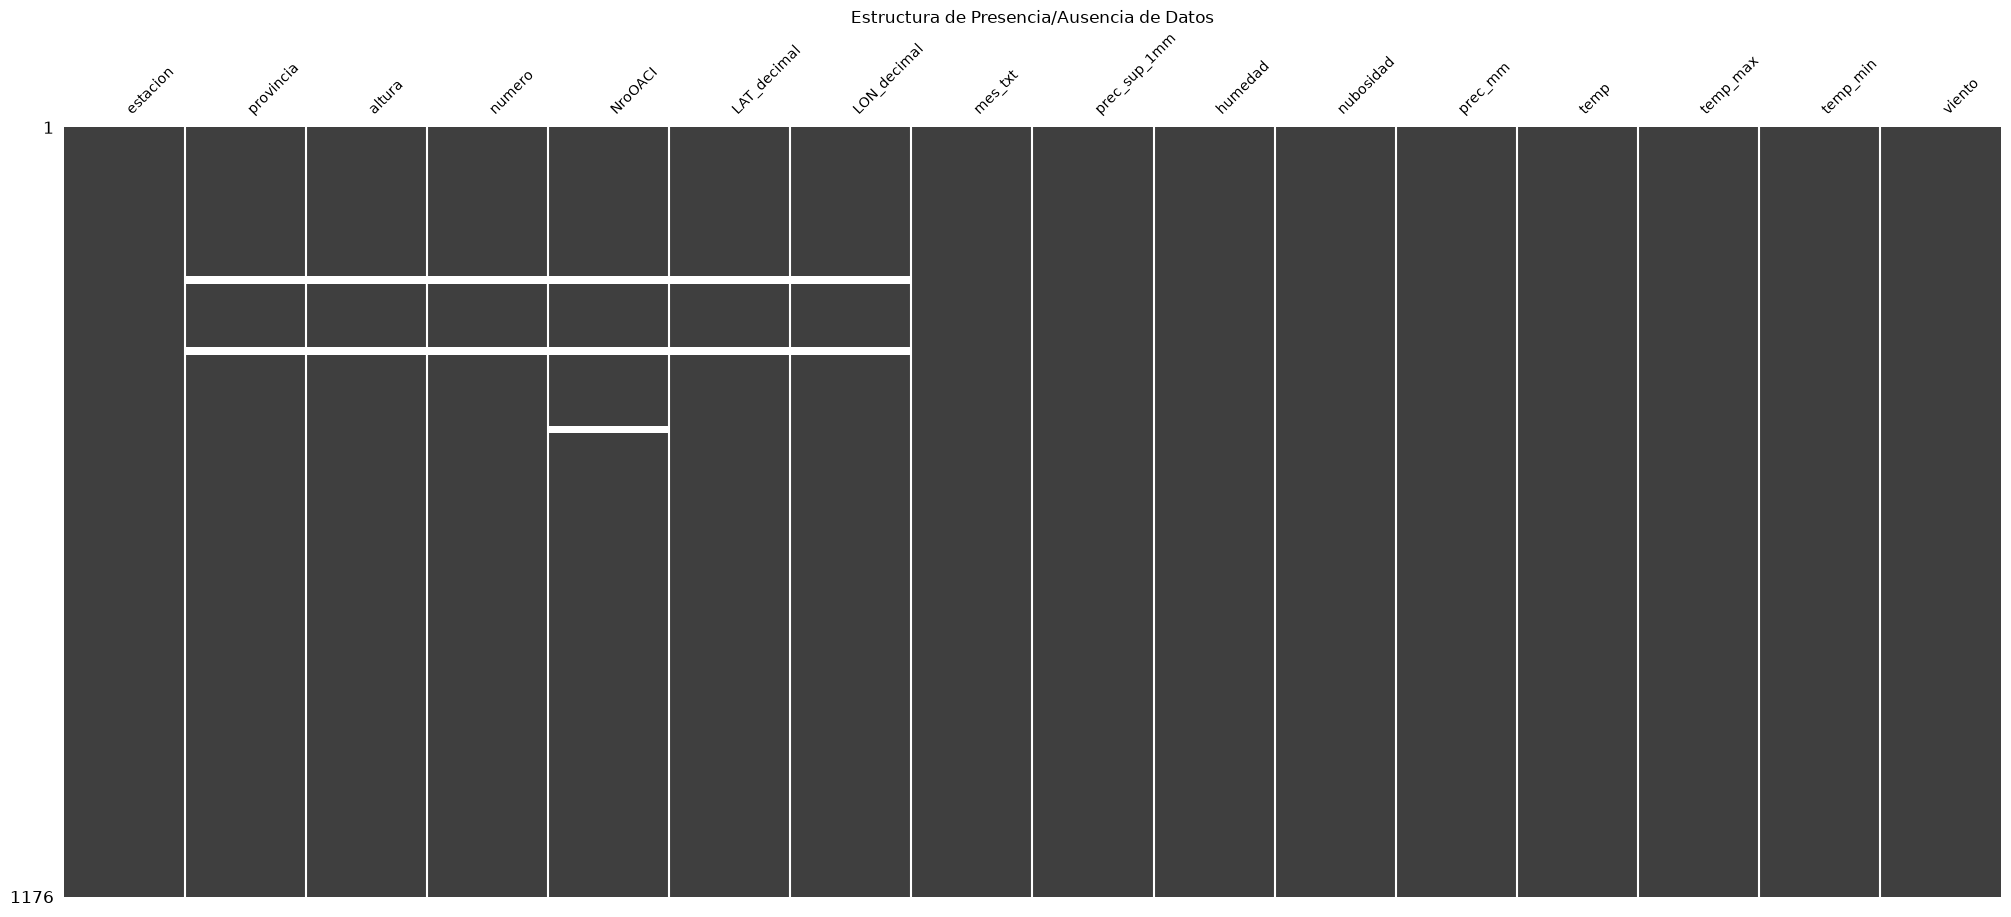

In [9]:
# Diagnóstico inicial de datos nulos
nulos = df_csv.isnull().sum()
porcentaje_nulos = (nulos / len(df_csv)) * 100
tabla_nulos = pd.DataFrame({'cantidad de nulos': nulos, 'Porcentaje': porcentaje_nulos})

print("--Tabla de nulos--")
print(tabla_nulos[tabla_nulos['cantidad de nulos']>0])

#DIAGNOSTICO VISUAL Y PRUEBA DE MECANISMO MAR
plt.figure(figsize=(10,4))
msno.matrix(df_csv, sparkline=False, fontsize=10)
plt.title("Estructura de Presencia/Ausencia de Datos")
plt.show()

Como voy a trabajar sobre la región de cuyo:
- Corroboro mayúsculas y minusculas, con espacios y tildes
- Defino mis provincias de la region de Cuyo

In [10]:
df_csv['provincia_clean'] = (
    df_csv['provincia']
    .astype(str)
    .str.strip()
    .str.upper()
    .str.normalize('NFKD')
    .str.encode('ascii', errors='ignore')
    .str.decode('utf-8')
)

provincia_cuyo = ['MENDOZA', 'SAN JUAN' , 'SAN LUIS', 'LA RIOJA']

df_cuyo = df_csv[df_csv['provincia_clean'].isin(provincia_cuyo)].copy()

print(f"Filas totales provincias: {len(df_csv)}")
print(f"Filas de Cuyo: {len(df_cuyo)}")
print(f"Provincias presentes en Cuyo:" , df_cuyo['provincia_clean'].unique())


Filas totales provincias: 1176
Filas de Cuyo: 144
Provincias presentes en Cuyo: <StringArray>
['LA RIOJA', 'SAN JUAN', 'MENDOZA', 'SAN LUIS']
Length: 4, dtype: str


In [15]:
cantidad_estacion = df_cuyo['estacion'].unique()
print(f"EStaciones meteorologicas {cantidad_estacion}")

altura_estacion = df_cuyo['altura'].unique()
print(f" Altura de las estaciones {altura_estacion}")

altura_estacion = df_cuyo.groupby('estacion')['altura'].first()

altura_promedio = altura_estacion.mean()

print(f"Altura media por estacion: {altura_promedio:.2f}")

EStaciones meteorologicas <StringArray>
[       'CHAMICAL AERO',       'CHILECITO AERO',               'JACHAL',
        'LA RIOJA AERO',        'MALARGUE AERO',         'MENDOZA AERO',
 'MENDOZA OBSERVATORIO',        'SAN JUAN AERO',        'SAN LUIS AERO',
     'SAN MARTIN (MZA)',      'SAN RAFAEL AERO',  'VILLA REYNOLDS AERO']
Length: 12, dtype: str
 Altura de las estaciones [ 461.  947. 1175.  429. 1425.  704.  827.  598.  713.  653.  748.  486.]
Altura media por estacion: 763.83


Visualización de la distribucion de alturas

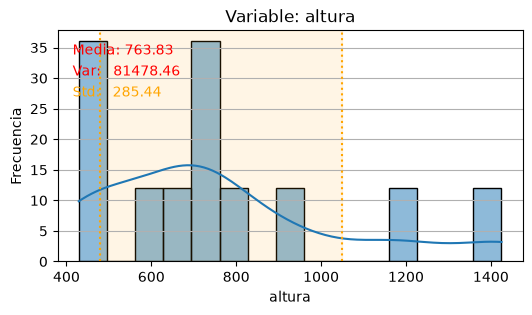

In [16]:
plot_histograma(df_cuyo, 'altura')

Cuando hice el .info() hay varios datos que son numericos y se leen como string.
Convierto las columnas numericas que se leyero como string

In [27]:
columnas_numericas = ['temp', 'prec_mm', 'temp_max', 'temp_min', 'humedad', 'viento', 'nubosidad', 'prec_sup_1mm']

for col in columnas_numericas:
    if col in df_cuyo.columns:
        df_cuyo[col] = df_cuyo[col].astype(str).str.replace(',', '.') #REEMPLAZO LAS COMAS POR PUNTO
        df_cuyo[col] = pd.to_numeric(df_cuyo[col], errors = 'coerce')

print(df_cuyo[['temp', 'prec_mm', 'altura']].dtypes)



temp       float64
prec_mm    float64
altura     float64
dtype: object
La temperatura media es:  17.06
EL desvio de la temperatura es: {desvio_temperatura: .2f}
Precipitaciones media por mes mes_txt
Ene    59.05
Feb    55.78
Dic    48.69
Mar    48.23
Nov    37.06
Abr    26.24
Oct    23.32
May    14.16
Sep    13.02
Ago     9.08
Jun     7.20
Jul     6.85
Name: prec_mm, dtype: float64
Mes con mayor precipitación media: Ene (59.05 mm)
Temperatura media por provincia provincia_clean
LA RIOJA    19.58
SAN JUAN    17.40
SAN LUIS    16.65
MENDOZA     15.59
Name: temp, dtype: float64
Provincia con mayor temperatura media: LA RIOJA (19.58 °C)


In [28]:
temperatura_media = df_cuyo['temp'].mean()
print(f"La temperatura media es: {temperatura_media: .2f}")

La temperatura media es:  17.06


In [36]:
desvio_temperatura = df_cuyo['temp'].std()
print(f"EL desvio de la temperatura es: {desvio_temperatura.round(2)}")


EL desvio de la temperatura es: 6.3


In [31]:
precipitaciones_por_mes = df_cuyo.groupby('mes_txt')['prec_mm'].mean().sort_values(ascending=False)
print(f"Precipitaciones media por mes {precipitaciones_por_mes.round(2)}")
print(f"Mes con mayor precipitación media: {precipitaciones_por_mes.index[0]} ({precipitaciones_por_mes.iloc[0]:.2f} mm)")


Precipitaciones media por mes mes_txt
Ene    59.05
Feb    55.78
Dic    48.69
Mar    48.23
Nov    37.06
Abr    26.24
Oct    23.32
May    14.16
Sep    13.02
Ago     9.08
Jun     7.20
Jul     6.85
Name: prec_mm, dtype: float64
Mes con mayor precipitación media: Ene (59.05 mm)


In [33]:
temp_por_provincia = df_cuyo.groupby('provincia_clean')['temp'].mean().sort_values(ascending=False)

print(f"Temperatura media por provincia {temp_por_provincia.round(2)}")
print(f"Provincia con mayor temperatura media: {temp_por_provincia.index[0]} ({temp_por_provincia.iloc[0]:.2f})")

Temperatura media por provincia provincia_clean
LA RIOJA    19.58
SAN JUAN    17.40
SAN LUIS    16.65
MENDOZA     15.59
Name: temp, dtype: float64
Provincia con mayor temperatura media: LA RIOJA (19.58)


Detección de Outliers (IQR)
Cantidad de outliers en 'temp': 0
Cantidad de outliers en 'prec_mm': 14


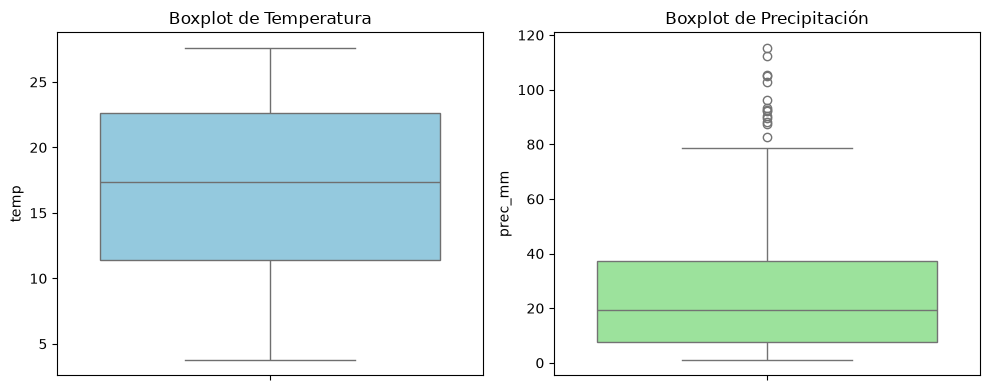

Correlación de Spearman
Coeficiente de Spearman (Altura vs Temp): -0.2092
Eta cuadrado (Provincia vs Precipitación): 0.2803


In [38]:

# VALORES ATÍPICOS (OUTLIERS) CON CRITERIO IQR

def contar_outliers_iqr(df_sub, columna):
  q1 = df_sub[columna].quantile(0.25)
  q3 = df_sub[columna].quantile(0.75)
  iqr = q3 - q1
  lim_inf = q1 - 1.5 * iqr
  lim_sup = q3 + 1.5 * iqr
  outliers = df_sub[
      (df_sub[columna] < lim_inf) | (df_sub[columna] > lim_sup)
  ]
  return len(outliers)


outliers_temp = contar_outliers_iqr(df_cuyo, "temp")
outliers_prec = contar_outliers_iqr(df_cuyo, "prec_mm")

print("Detección de Outliers (IQR)")
print(f"Cantidad de outliers en 'temp': {outliers_temp}")
print(f"Cantidad de outliers en 'prec_mm': {outliers_prec}")

# Gráfico de Boxplots comparativo
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(y=df_cuyo["temp"], ax=axes[0], color="skyblue")
axes[0].set_title("Boxplot de Temperatura")

sns.boxplot(y=df_cuyo["prec_mm"], ax=axes[1], color="lightgreen")
axes[1].set_title("Boxplot de Precipitación")
plt.tight_layout()
plt.show()


# CORRELACIÓN DE SPEARMAN (ALTURA VS TEMPERATURA)

df_spearman = df_cuyo[["altura", "temp"]].dropna()
rho, p_val = spearmanr(df_spearman["altura"], df_spearman["temp"])

print("Correlación de Spearman")
print(f"Coeficiente de Spearman (Altura vs Temp): {rho:.4f}")


# ETA CUADRADO (PROVINCIA VS PRECIPITACIÓN)

def calcular_eta_cuadrado(df_sub, cat_col, num_col):
  df_valid = df_sub[[cat_col, num_col]].dropna()
  grand_mean = df_valid[num_col].mean()
  ss_total = ((df_valid[num_col] - grand_mean) ** 2).sum()

  group_means = df_valid.groupby(cat_col)[num_col].mean()
  group_counts = df_valid.groupby(cat_col)[num_col].count()
  ss_between = (group_counts * (group_means - grand_mean) ** 2).sum()

  return ss_between / ss_total


eta2 = calcular_eta_cuadrado(df_cuyo, "provincia_clean", "prec_mm")


print(f"Eta cuadrado (Provincia vs Precipitación): {eta2:.4f}")

CALCULOS UNICAMENTE DE MENDOZA


In [39]:
df_mendoza = df_cuyo [df_cuyo['provincia_clean'] == 'MENDOZA'].copy()

for col in ['prec_mm', 'humedad']:
    df_mendoza[col] = pd.to_numeric(df_mendoza[col].astype(str).str.replace(',', '.'), errors='coerce')

Promedios generales de mendoza:
- precipitacion media y humedad

In [40]:
precipitacion_media = df_mendoza['prec_mm'].mean()

humedad_media = df_mendoza['humedad'].mean()

print(f"Precipitacion media de mendoza: {precipitacion_media: .2f}")

print(f"HUmedad media de mendoza: {humedad_media: .2f}")



Precipitacion media de mendoza:  24.19
HUmedad media de mendoza:  56.09


In [41]:
print(df_mendoza[['prec_mm', 'humedad']].describe().round(2))

       prec_mm  humedad
count    60.00    60.00
mean     24.18    56.09
std      13.56     8.10
min       3.10    40.00
25%      12.02    49.92
50%      23.85    54.10
75%      32.67    63.28
max      54.20    70.40
